https://www.kaggle.com/datasets/aczy156/software-defect-prediction-nasa?resource=download

In [1]:
import pandas as pd
from scipy.io import arff

# Load the ARFF file
data, meta = arff.loadarff('JM1.arff')

# Convert the record array to a pandas DataFrame
df = pd.DataFrame(data)

# Decode byte strings in object columns (if necessary)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

df.head()

,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,HALSTEAD_DIFFICULTY,...,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL,label
0,1.0,7.0,0.0,0.0,4.0,3.0,1.0,11.0,25.05,11.20,...,59.0,0.09,174.56,280.54,28.0,31.0,15.0,12.0,14.0,N
1,5.0,37.0,0.0,6.0,19.0,16.0,10.0,85.0,81.19,27.41,...,351.0,0.04,3388.22,2225.29,147.0,204.0,59.0,22.0,98.0,N
2,2.0,1.0,0.0,0.0,1.0,1.0,1.0,10.0,56.44,2.83,...,37.0,0.35,25.17,159.91,17.0,20.0,15.0,5.0,14.0,Y
3,16.0,1.0,0.0,0.0,1.0,1.0,1.0,52.0,168.57,16.97,...,450.0,0.06,2697.42,2860.90,198.0,252.0,70.0,12.0,70.0,Y
4,0.0,7.0,0.0,0.0,4.0,2.0,3.0,9.0,14.32,7.71,...,26.0,0.13,47.33,110.45,9.0,17.0,7.0,12.0,12.0,N


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7782 entries, 0 to 7781
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LOC_BLANK              7782 non-null   float64
 1   BRANCH_COUNT           7782 non-null   float64
 2   LOC_CODE_AND_COMMENT   7782 non-null   float64
 3   LOC_COMMENTS           7782 non-null   float64
 4   CYCLOMATIC_COMPLEXITY  7782 non-null   float64
 5   DESIGN_COMPLEXITY      7782 non-null   float64
 6   ESSENTIAL_COMPLEXITY   7782 non-null   float64
 7   LOC_EXECUTABLE         7782 non-null   float64
 8   HALSTEAD_CONTENT       7782 non-null   float64
 9   HALSTEAD_DIFFICULTY    7782 non-null   float64
 10  HALSTEAD_EFFORT        7782 non-null   float64
 11  HALSTEAD_ERROR_EST     7782 non-null   float64
 12  HALSTEAD_LENGTH        7782 non-null   float64
 13  HALSTEAD_LEVEL         7782 non-null   float64
 14  HALSTEAD_PROG_TIME     7782 non-null   float64
 15  HALS

1. LOC_BLANK: Número de líneas en blanco
2. BRANCH_COUNT: Número de bifurcaciones en el flujo de control
3. LOC_CODE_AND_COMMENT: Número de líneas que contienen tanto código como comentarios
4. LOC_COMMENTS: Número de líneas de comentarios
5. CYCLOMATIC_COMPLEXITY: Complejidad ciclomática - mide el número de caminos independientes a través del código
6. DESIGN_COMPLEXITY: Complejidad de diseño - mide la complejidad de la estructura del módulo
7. ESSENTIAL_COMPLEXITY: Complejidad esencial - mide el grado de estructuración del código
8. LOC_EXECUTABLE: Número de líneas de código ejecutables
9. HALSTEAD_CONTENT: Contenido de información del programa
10. HALSTEAD_DIFFICULTY: Dificultad del programa - qué tan difícil es escribir/entender el código
11. HALSTEAD_EFFORT: Esfuerzo mental requerido para desarrollar o entender el programa
12. HALSTEAD_ERROR_EST: Estimación de errores entregados en el software
13. HALSTEAD_LENGTH: Longitud total del programa (operadores + operandos)
14. HALSTEAD_LEVEL: Nivel del programa - inverso de la dificultad
15. HALSTEAD_PROG_TIME: Tiempo estimado para programar
16. HALSTEAD_VOLUME: Volumen del programa - tamaño del algoritmo implementado
17. NUM_OPERANDS: Número total de operandos en el código
18. NUM_OPERATORS: Número total de operadores en el código
19. NUM_UNIQUE_OPERANDS: Número de operandos únicos/distintos
20. NUM_UNIQUE_OPERATORS: Número de operadores únicos/distintos
21. LOC_TOTAL: Total de líneas de código
22. label: Indica si el módulo contiene defectos (Y = Yes/Sí, N = No)

In [3]:
df.shape

(7782, 22)

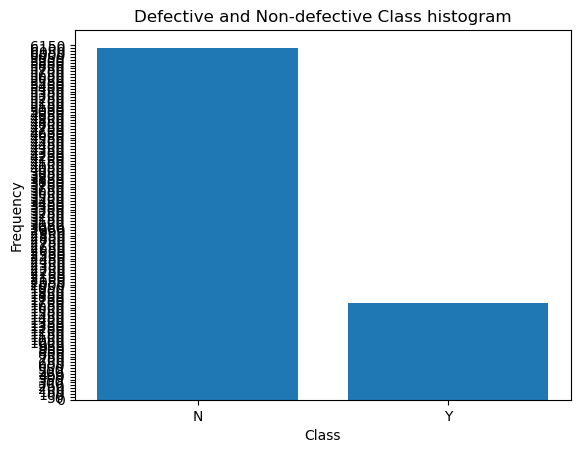

In [5]:
#Defective and Non-defective Class histogram
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = df['label'].value_counts()

# Plot the histogram
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Defective and Non-defective Class histogram')
plt.xticks(rotation=0)
# show more numbers in frequency (y axis)
plt.gca().set_yticks(range(0, class_counts.max() + 50, 50))
# show the grid
# plt.grid(axis='y')
plt.show()

In [6]:
class_counts

label
N    6110
Y    1672
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='LOC_TOTAL'>

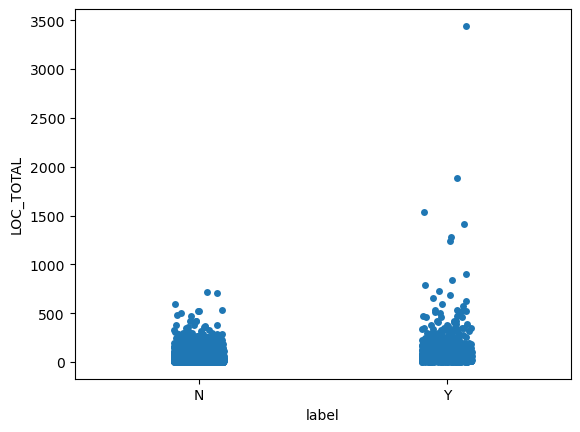

In [9]:
# Dispersion plot of class Defective
import seaborn as sns

sns.stripplot(x='label', y='LOC_TOTAL', data=df, jitter=True)

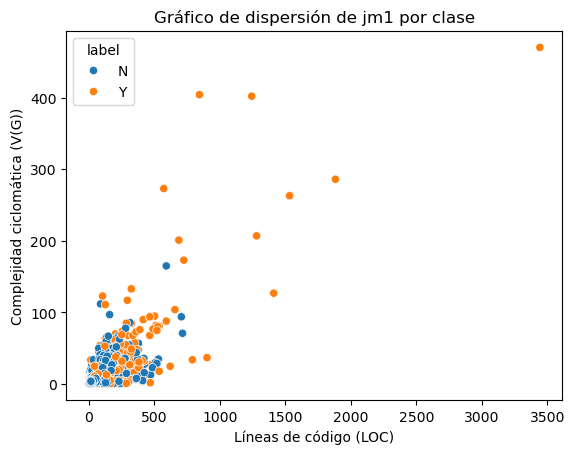

In [11]:
# Suponiendo que las columnas relevantes para la visualización se llaman 'metric_1', 'metric_2' y 'class'
# Reemplaza 'metric_1' y 'metric_2' con los nombres reales de las columnas que quieres visualizar.
# 'class' es la columna que contiene la etiqueta de clase (defecto o no defecto).
sns.scatterplot(x='LOC_TOTAL', y='CYCLOMATIC_COMPLEXITY', hue='label', data=df)

# Añadir títulos y etiquetas
plt.title('Gráfico de dispersión de jm1 por clase')
plt.xlabel('Líneas de código (LOC)')
plt.ylabel('Complejidad ciclomática (V(G))')
plt.show()